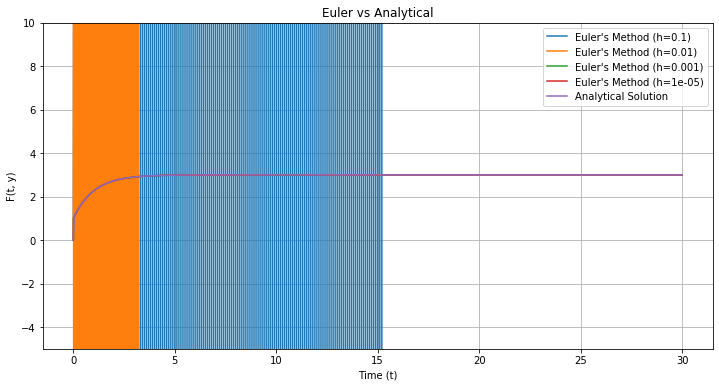

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import warnings

# Filter out RuntimeWarnings specifically
warnings.filterwarnings('ignore', category=RuntimeWarning)

# Parameters
h_values = [.1, .01, .001, .00001]


def f(t, y):
    return (-1000*y) + 3000 - (2000*np.exp(-t))

trueY = lambda t: 3 - 0.998*np.exp(-1000*t) - 2.002*np.exp(-t)

        
        
# Function to apply Euler's Method for given step size

def euler_method(h, t_start, t_end, y_0):
    t_values = np.arange(t_start, t_end + h, h)
    y_values = np.zeros(len(t_values))
    # Set initial conditions
    y_values[0] = y_0

    for i in range(1, len(t_values)):       
        # Update equations for Euler's Method
        y_values[i] = y_values[i-1] + h * f(t_values[i-1], y_values[i-1])
 
    return t_values, y_values

# Plot results for different step sizes
plt.figure(figsize=(12, 6))

for h in h_values:
    t_start = 0    # Start time
    t_end = 30     # End time
    t, y = euler_method(h, t_start, t_end, 0)
    plt.plot(t, y, label=f'Euler\'s Method (h={h})')

tExact = np.linspace(t_start, t_end, 1000)
plt.plot(tExact, trueY(tExact), label="Analytical Solution")

plt.xlabel('Time (t)')
plt.ylabel('F(t, y)')

plt.title('Euler vs Analytical')
plt.ylim(-5, 10)

plt.legend(loc='upper right')
plt.grid(True)
plt.show()

#I asked Gemini 3 Fast to guide me on how to remove Runtime warning error: "How do I ignore runtime warning from overflow in jupyter notebook python"
#This led me to importing "warnings" library and filtering the warning. I also inputed the code and asked how to limit it and it gave me 
# "Restrict the y-axis so the unstable explosions (h=0.1, h=0.01) don't ruin the view
# plt.ylim(-5, 10)"